# BrushCue Example: Camera Moving Distortion

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/camera_moving_distortion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/camera-moving-distortion

In [ ]:
!pip install brushcue

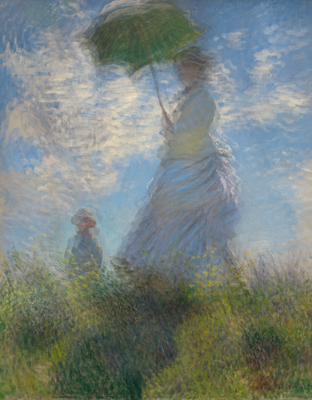

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
alpha_transform_2 = brushcue.composition_linear_transform(input_image_1, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.3)
transform_2d_identity_3 = brushcue.transform2_identity()
vector_2_float_from_components_4 = brushcue.vector2f_from_components(21.0, 46.0)
transform_2d_identity_5 = brushcue.transform2_identity()
vector_2_float_from_components_6 = brushcue.vector2f_from_components(39.0, -20.0)
composition_size_7 = brushcue.composition_size(input_image_1)
second_image_offset_8 = brushcue.vector2f_constant(-60, 19.9571)
first_image_offset_9 = brushcue.vector2f_constant(40, 60)
transform_2d_translation_10 = brushcue.transform2_translation(transform_2d_identity_3, vector_2_float_from_components_4)
transform_2d_translation_11 = brushcue.transform2_translation(transform_2d_identity_5, vector_2_float_from_components_6)
composition_width_12 = brushcue.vector2i_x(composition_size_7)
composition_height_13 = brushcue.vector2i_y(composition_size_7)
vector_2_float_get_x_14 = brushcue.vector2f_x(second_image_offset_8)
vector_2_float_get_x_15 = brushcue.vector2f_x(first_image_offset_9)
vector_2_float_get_y_16 = brushcue.vector2f_y(first_image_offset_9)
vector_2_float_get_y_17 = brushcue.vector2f_y(second_image_offset_8)
min_x_offset_18 = brushcue.float_min(vector_2_float_get_x_15, vector_2_float_get_x_14)
min_y_offset_19 = brushcue.float_min(vector_2_float_get_y_16, vector_2_float_get_y_17)
first_blend_20 = brushcue.composition_blend_alpha(alpha_transform_2, input_image_1, transform_2d_translation_11)
max_x_offset_21 = brushcue.float_max(vector_2_float_get_x_14, vector_2_float_get_x_15)
max_y_offset_22 = brushcue.float_max(vector_2_float_get_y_16, vector_2_float_get_y_17)
float_round_to_int_23 = brushcue.float_round_to_int(min_x_offset_18)
float_round_to_int_24 = brushcue.float_round_to_int(min_y_offset_19)
second_blend_25 = brushcue.composition_blend_alpha(alpha_transform_2, first_blend_20, transform_2d_translation_10)
float_x_offset_26 = brushcue.float_max(max_x_offset_21, 0.0)
float_max_27 = brushcue.float_max(0.0, max_y_offset_22)
x_offset_right_28 = brushcue.int_multiply(float_round_to_int_23, -1)
int_multiply_29 = brushcue.int_multiply(float_round_to_int_24, -1)
x_offset_left_to_int_30 = brushcue.float_round_to_int(float_x_offset_26)
y_offset_top_to_int_31 = brushcue.float_round_to_int(float_max_27)
int_subtract_32 = brushcue.int_subtract(composition_width_12, x_offset_left_to_int_30)
int_max_33 = brushcue.int_max(x_offset_right_28, 0)
int_subtract_34 = brushcue.int_subtract(composition_height_13, y_offset_top_to_int_31)
int_max_35 = brushcue.int_max(int_multiply_29, 0)
int_subtract_36 = brushcue.int_subtract(int_subtract_32, int_max_33)
int_subtract_37 = brushcue.int_subtract(int_subtract_34, int_max_35)
bounds_2d_int_from_x_y_width_height_38 = brushcue.bounds2i_from_x_y_width_height(x_offset_left_to_int_30, y_offset_top_to_int_31, int_subtract_36, int_subtract_37)
cropped_output_39 = brushcue.composition_crop(second_blend_25, bounds_2d_int_from_x_y_width_height_38)

ctx = brushcue.Context()
result = cropped_output_39.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
